In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv("/content/Salary.csv")

In [48]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


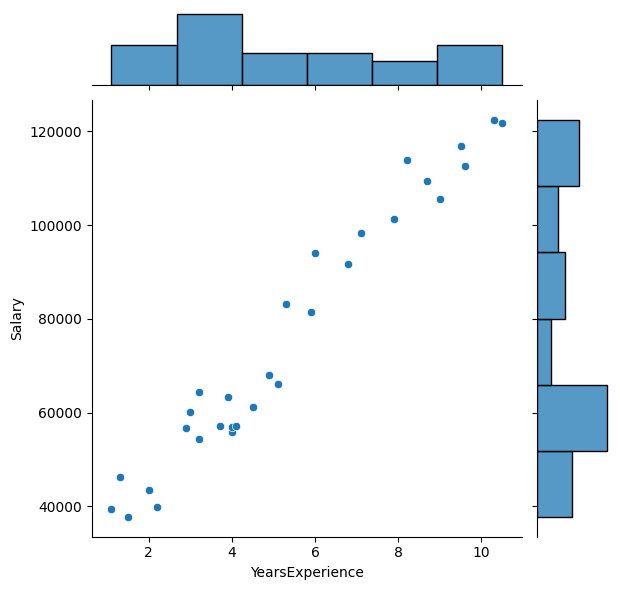

In [49]:
sns.jointplot( x="YearsExperience",y="Salary",data = df)

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
x = df[['YearsExperience']]
y = df['Salary']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [53]:
from sklearn.linear_model import LinearRegression

In [54]:
lm = LinearRegression()
lm.fit(X_train,y_train)
lm.coef_

array([9423.81532303])

In [55]:
prediction = lm.predict(X_test)

In [56]:
prediction

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

Text(0.5, 1.0, 'Evaluation of our ML model')

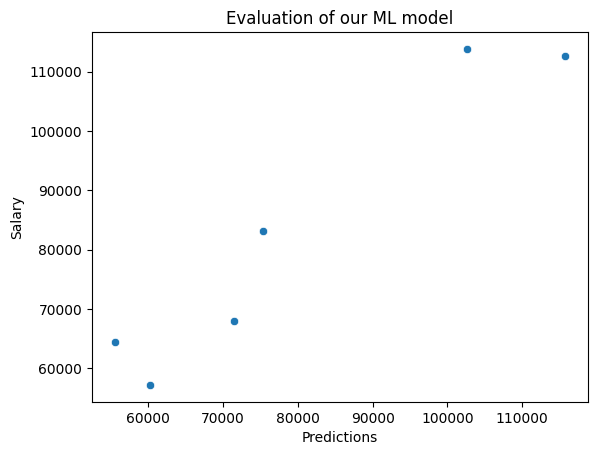

In [57]:
sns.scatterplot(x=prediction,y=y_test)
plt.xlabel('Predictions')
plt.title('Evaluation of our ML model')

In [58]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
import math

In [59]:
print("Mean Absolute Error:", mean_absolute_error(y_test,prediction))
print("Mean Squared Error:",mean_squared_error(y_test,prediction))
print("RMSE:",math.sqrt(mean_squared_error(y_test,prediction)))

Mean Absolute Error: 6286.453830757749
Mean Squared Error: 49830096.85590839
RMSE: 7059.04362190151


In [60]:
residual = y_test - prediction
residual

,Salary
27,-3155.210113
15,-3560.278095
23,11215.131339
17,7820.195776
8,8967.207955
9,-3000.699707


In [61]:
import pylab

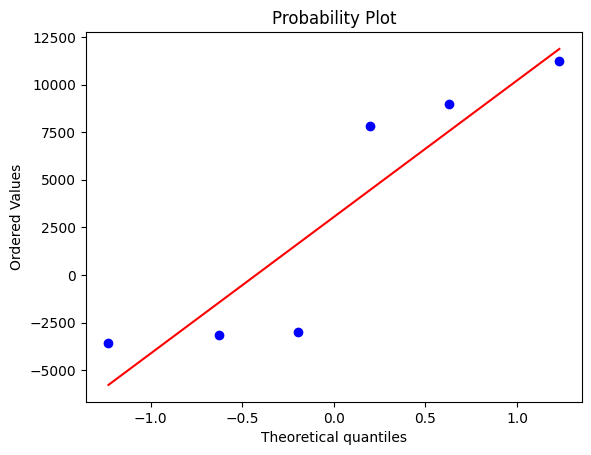

In [62]:
import scipy.stats as stats
stats.probplot(residual, dist="norm", plot=pylab)
pylab.show()

In [64]:
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, prediction))

R2 Score: 0.9024461774180497
